## Import et préparation des image

In [8]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import os
from PIL import Image
from tqdm import tqdm
from collections import Counter


print(torch.backends.mps.is_available())

True


In [ ]:
import random

class BalancedPneumoniaDataset(Dataset):
    def __init__(self, root_dir, transform=None, max_per_class=1300):
        self.root_dir = root_dir
        self.transform = transform
        self.data = []
        self.labels = []

        class_data = {0: [], 1: [], 2: []}

        for folder in ['NORMAL', 'PNEUMONIA']:
            folder_path = os.path.join(root_dir, folder)
            for file_name in os.listdir(folder_path):
                file_path = os.path.join(folder_path, file_name)
                
                if not file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    continue

                if folder == 'NORMAL':
                    class_data[0].append(file_path)
                elif 'bacteria' in file_name.lower():
                    class_data[1].append(file_path)
                elif 'virus' in file_name.lower():
                    class_data[2].append(file_path)

        for class_id, files in class_data.items():
            if len(files) > max_per_class:
                files = random.sample(files, max_per_class)
            self.data.extend(files)
            self.labels.extend([class_id] * len(files))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(
        degrees=20, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10
    ),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_data = BalancedPneumoniaDataset('../dataset/train', transform=train_transform)
val_data = BalancedPneumoniaDataset('../dataset/val', transform=val_test_transform)
test_data = BalancedPneumoniaDataset('../dataset/test', transform=val_test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)

from collections import Counter

class_counts = Counter()

for _, labels in train_loader:
    class_counts.update(labels.numpy())

for class_id, count in class_counts.items():
    print(f"Classe {class_id}: {count} images")


Classe 1: 1300 images
Classe 2: 1300 images
Classe 0: 1300 images


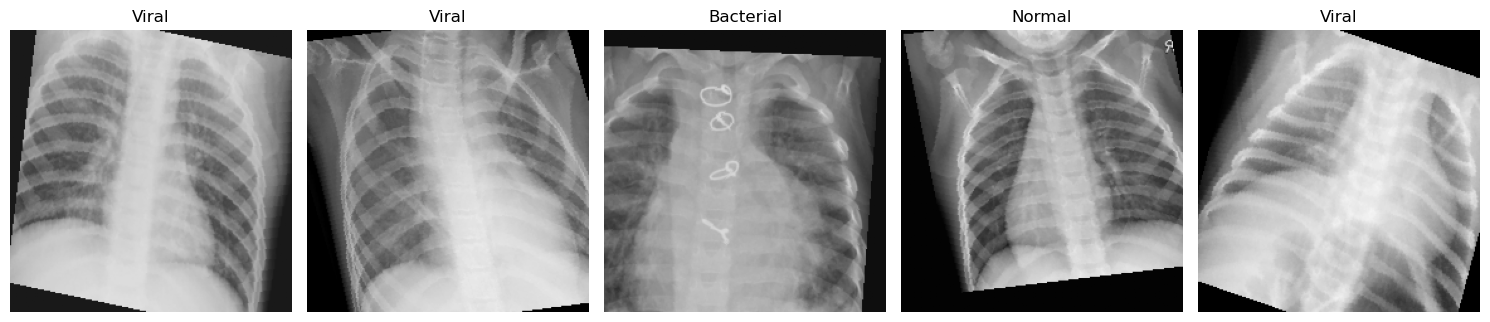

In [ ]:
import matplotlib.pyplot as plt

class_names = ["Normal", "Bacterial", "Viral"]

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 5, figsize=(15,5))

for i in range(5):
    axes[i].imshow(images[i].permute(1, 2, 0))
    axes[i].set_title(class_names[labels[i]])
    axes[i].axis('off')

plt.tight_layout()
plt.show()


## Charger le modèle

In [ ]:
from torchvision.models import efficientnet_b0
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Appareil utilisé : {device}")

model = efficientnet_b0(pretrained=True)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 3)

for param in model.parameters():
    param.requires_grad = True

model.to(device)

Appareil utilisé : mps


/opt/homebrew/Caskroom/miniconda/base/envs/zoidberg/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/zoidberg/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

## Entraînement Modèle

In [ ]:
weights = torch.tensor([1.0, 1.0, 2.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, verbose=True
)

epochs = 30
patience = 10
early_stop_counter = 0
best_val_loss = float("inf")
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    print(f"\nEpoch {epoch+1}/{epochs}")

    for images, labels in tqdm(train_loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), "best_efficientnet_model.pth")
        print("Meilleur modèle sauvegardé.")
    else:
        early_stop_counter += 1
        print(f"⏳ Patience : {early_stop_counter}/{patience}")
        if early_stop_counter >= patience:
            print("Early stopping activé.")
            break

    scheduler.step(avg_val_loss)


Epoch 1/30


/opt/homebrew/Caskroom/miniconda/base/envs/zoidberg/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Train Loss: 0.6462 | Val Loss: 1.6817
✅ Meilleur modèle sauvegardé.

Epoch 2/30


Train Loss: 0.5282 | Val Loss: 0.8426
✅ Meilleur modèle sauvegardé.

Epoch 3/30


Train Loss: 0.5078 | Val Loss: 0.7798
✅ Meilleur modèle sauvegardé.

Epoch 4/30


...

Train Loss: 0.3132 | Val Loss: 1.3830
⏳ Patience : 6/10

Epoch 13/30


Train Loss: 0.2544 | Val Loss: 1.1759
⏳ Patience : 7/10

Epoch 14/30


Train Loss: 0.2456 | Val Loss: 1.3621
⏳ Patience : 8/10

Epoch 15/30


Train Loss: 0.2112 | Val Loss: 1.8464
⏳ Patience : 9/10

Epoch 16/30


Train Loss: 0.1937 | Val Loss: 1.2816
⏳ Patience : 10/10
🛑 Early stopping activé.


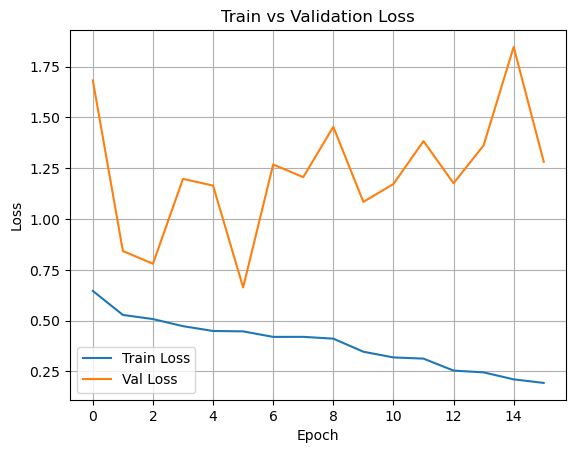

In [14]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model.load_state_dict(torch.load("best_efficientnet_model.pth"))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("\n Rapport final sur le test set :\n")
print(classification_report(
    y_true, y_pred,
    labels=[0, 1, 2],
    target_names=["NORMAL", "BACTERIAL", "VIRAL"]
))

print("Matrice de confusion :")
print(confusion_matrix(y_true, y_pred))


✅ Rapport final sur le test set :

              precision    recall  f1-score   support

      NORMAL       0.94      0.91      0.93       234
   BACTERIAL       0.87      0.97      0.91       242
       VIRAL       0.86      0.74      0.80       148

    accuracy                           0.89       624
   macro avg       0.89      0.87      0.88       624
weighted avg       0.89      0.89      0.89       624

Matrice de confusion :
[[213   6  15]
 [  5 234   3]
 [  8  30 110]]


## Bloc Grad-CAM automatique (multi-images)

/opt/homebrew/Caskroom/miniconda/base/envs/zoidberg/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/zoidberg/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/opt/homebrew/Caskroom/miniconda/base/envs/zoidberg/lib/python3.10/site-packages/torch/nn/modules/module.py:1831: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be

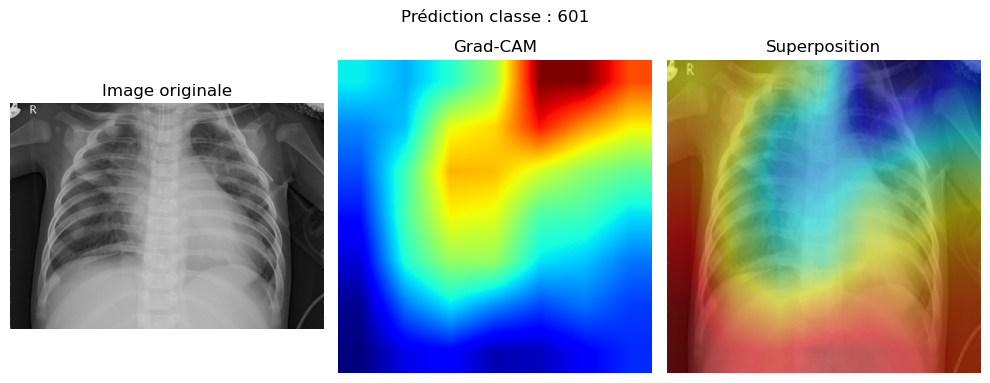

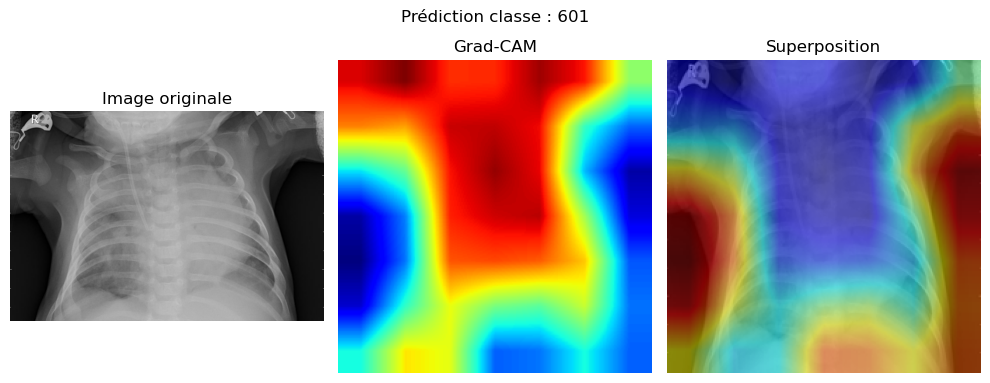

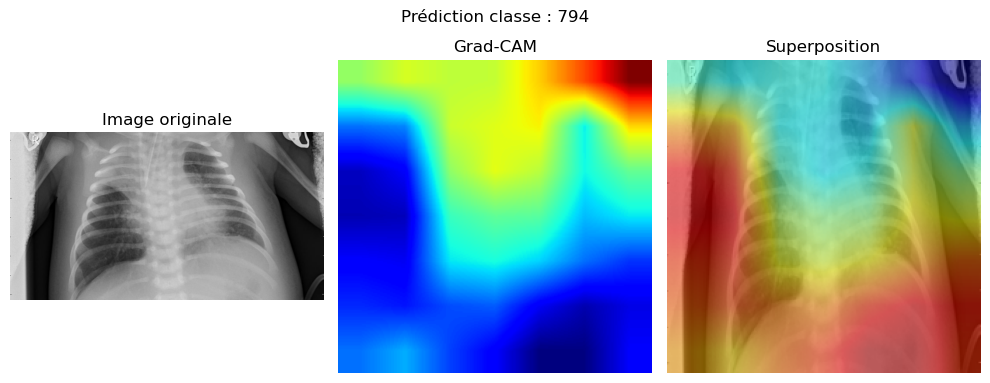

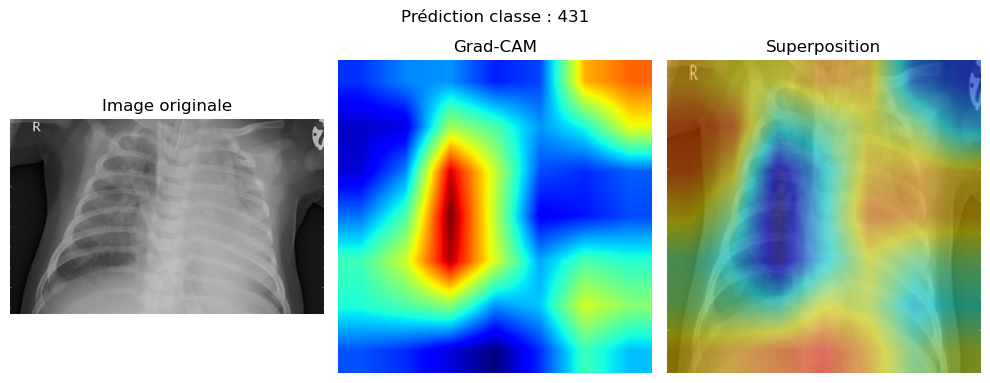

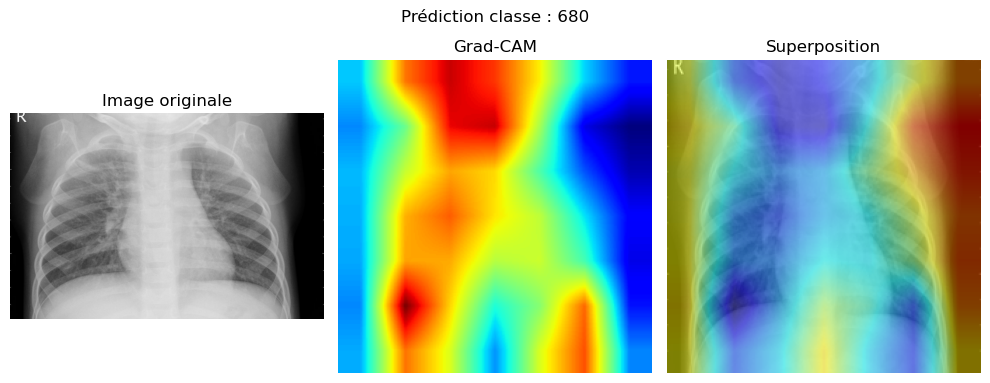

In [ ]:
from torchvision.models import efficientnet_b0
import os
from glob import glob
import cv2
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch

model = efficientnet_b0(pretrained=True)
model.eval()
target_layer = model.features[-1][1]

activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output.detach()

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0].detach()

target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])

image_paths = glob("../dataset/test/PNEUMONIA/*.jpeg")[:5]

for path in image_paths:
    img_pil = Image.open(path).convert("RGB")
    img_tensor = transform(img_pil).unsqueeze(0)

    output = model(img_tensor)
    pred_class = output.argmax(dim=1).item()

    model.zero_grad()
    output[0, pred_class].backward()

    weights = gradients.mean(dim=(2, 3), keepdim=True)
    cam = (weights * activations).sum(dim=1).squeeze()
    cam = torch.relu(cam)
    cam = cam / cam.max()
    cam = cam.cpu().numpy()

    cam_resized = cv2.resize(cam, (224, 224))
    img_np = np.array(img_pil.resize((224, 224)))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    superimposed = cv2.addWeighted(img_np, 0.5, heatmap, 0.5, 0)

    plt.figure(figsize=(10, 4))
    plt.suptitle(f"Prédiction classe : {pred_class}")
    plt.subplot(1, 3, 1)
    plt.imshow(img_pil)
    plt.title("Image originale")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cam_resized, cmap="jet")
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(superimposed)
    plt.title("Superposition")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [17]:
torch.save(model.state_dict(), "efficientnet_trained.pth")
